# ResNet18 Baseline - 3600 Samples

This notebook trains a ResNet18 model for document type classification using 3600 samples from the dataset.

**Model Architecture:** ResNet18 (trained from scratch, no pre-training)  
**Dataset Size:** 3600 images (balanced across 3 classes)  
**Training Configuration:**
- Batch size: 128
- Learning rate: 0.0000001
- Epochs: 30
- Optimizer: Adam with weight decay 1e-4
- Dropout: 0.3


## Data Loading and Splitting

Load the dataset CSV file, sample 3600 images (if needed), and split into train/validation/test sets with stratified sampling to maintain class balance.


## Custom Dataset Class

Define a PyTorch Dataset class that loads images from file paths and applies transformations. Maps labels to numeric values (id_card=0, passport=1, driver_license=2).


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Set the number of images to use (None = use entire dataset)
SAMPLE_SIZE = 3600

df = pd.read_csv("/Users/roy-siftt/final-project/datasets/idnet/document_type_classification_country_split/data/dataset.csv")

print(f"Original dataset size: {len(df)} images")
print(f"\nOriginal distribution:")
print(df['label'].value_counts().sort_index())

# If we want a smaller dataset, sample proportionally
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)
    print(f"\nDataset size after sampling: {len(df)} images")
    print(f"\nDistribution after sampling:")
    print(df['label'].value_counts().sort_index())

# Split into train/test/val
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=42)

print(f"\n{'='*60}")
print(f"Final Split:")
print(f"{'='*60}")

print(f"\nTrain Set: {len(train_df)} images")
print(train_df['label'].value_counts().sort_index())
print(f"   Total: {train_df['label'].value_counts().sum()}")

print(f"\nValidation Set: {len(val_df)} images")
print(val_df['label'].value_counts().sort_index())
print(f"   Total: {val_df['label'].value_counts().sum()}")

print(f"\nTest Set: {len(test_df)} images")
print(test_df['label'].value_counts().sort_index())
print(f"   Total: {test_df['label'].value_counts().sum()}")

print(f"\n{'='*60}")
print(f"Saving files...")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"Files saved successfully!")
print(f"{'='*60}")

Original dataset size: 3600 images

Original distribution:
label
driver_license    1200
id_card           1200
passport          1200
Name: count, dtype: int64

Final Split:

Train Set: 2601 images
label
driver_license    867
id_card           867
passport          867
Name: count, dtype: int64
   Total: 2601

Validation Set: 459 images
label
driver_license    153
id_card           153
passport          153
Name: count, dtype: int64
   Total: 459

Test Set: 540 images
label
driver_license    180
id_card           180
passport          180
Name: count, dtype: int64
   Total: 540

Saving files...
Files saved successfully!


## Data Augmentation and Transforms

Define image transformations for training (with strong augmentation) and validation/test (without augmentation). Uses ImageNet normalization statistics.


In [2]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class DocumentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        # Normalize labels (lowercase + strip spaces)
        self.df['label'] = self.df['label'].str.lower().str.strip()

        # Label mapping
        self.label_map = {
            "id_card": 0,
            "passport": 1,
            "driver_license": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")

        label_str = row['label']

        if label_str not in self.label_map:
            raise ValueError(f"Label '{label_str}' not found in label_map!")

        label = self.label_map[label_str]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)

## Create DataLoaders

Create PyTorch DataLoaders for train, validation, and test sets with appropriate batch sizes and shuffling.


In [3]:
from torchvision import transforms

# Transform with strong data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),              # Random crop instead of center
    transforms.RandomHorizontalFlip(p=0.3),  # Horizontal flip sometimes
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(                  # Color/brightness changes
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomAffine(                 # Geometric transformations
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3)          # Random erasing
])

# Transform for validation/test - without augmentation
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


## ResNet18 Model Definition

Define the ResNet18 classifier model. The model is trained from scratch (no pre-training). The final fully connected layer is replaced with a dropout layer followed by a linear layer for 3 classes.


In [4]:
from torch.utils.data import DataLoader

# Use different transforms for train and val/test
train_dataset = DocumentDataset(pd.read_csv("train.csv"), train_transform)
val_dataset   = DocumentDataset(pd.read_csv("val.csv"), val_test_transform)
test_dataset  = DocumentDataset(pd.read_csv("test.csv"), val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")

Dataset sizes:
   Train: 2601
   Val:   459
   Test:  540


## Visualize Sample Batch

Display a sample batch of training images to verify data loading and augmentation are working correctly.


In [5]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.5):
        super(ResNet18Classifier, self).__init__()
        
        # Load ResNet18 pre-trained on ImageNet
        if pretrained:
            self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        else:
            self.resnet = models.resnet18(weights=None)
        
        # Replace the final layer and add Dropout for regularization
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.resnet(x)

## Verify Dataset Loading

Check that images and labels are being loaded correctly by printing sample paths and labels.


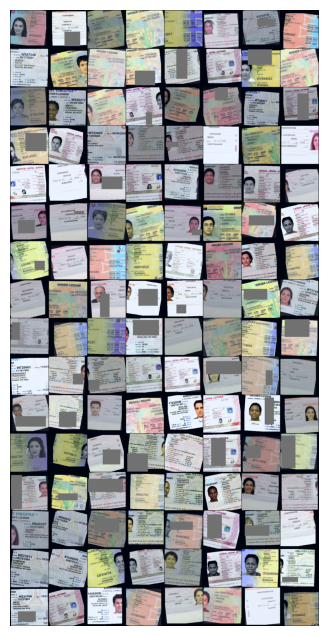

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def show_batch(loader):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs, nrow=8, normalize=True)
    plt.figure(figsize=(12,8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')

show_batch(train_loader)

## Training Setup and Execution

Initialize the model, loss function, and optimizer. Train the model for multiple epochs, evaluating on validation set after each epoch. Finally, evaluate on the test set and visualize training curves.


In [7]:
for i in range(10):
    print("PATH:", train_dataset.df.iloc[i]['image_path'])
    print("LABEL:", train_dataset.df.iloc[i]['label'])
    img, lbl = train_dataset[i]
    print("LOADER LABEL:", lbl)
    print("----")

PATH: images/01358.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/01873.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/02135.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/01918.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/00937.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/05096.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/03057.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/03293.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/01415.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/00944.png
LABEL: id_card
LOADER LABEL: tensor(0)
----


Using device: mps
Model: ResNet18 (Training from scratch - NO pre-training!)
Number of parameters: 11,178,051
Learning rate: 1e-07
Dropout: 0.3

Starting training...


=== Initial Evaluation (Before Training) ===

Sample predictions (first 20):
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓

Confusion Matrix:
[[  0 861   6]
 [  0 866   1]
 [  0 863   4]]

Train Acc (before): 0.3345
Val Acc (before):   0.3333

=== Epoch 1 ===


Training: 100%|██████████| 21/21 [00:57<00:00,  2.74s/it]


Train Loss: 1.1128 | Train Acc: 0.3353
Val   Loss: 1.1027 | Val   Acc: 0.4314

=== Epoch 2 ===


Training: 100%|██████████| 21/21 [00:53<00:00,  2.53s/it]


Train Loss: 1.1084 | Train Acc: 0.3456
Val   Loss: 1.0884 | Val   Acc: 0.3943

=== Epoch 3 ===


...

Train Loss: 1.0191 | Train Acc: 0.4125
Val   Loss: 0.9482 | Val   Acc: 0.6013

=== Epoch 29 ===


Training: 100%|██████████| 21/21 [00:50<00:00,  2.39s/it]


Train Loss: 1.0342 | Train Acc: 0.4018
Val   Loss: 0.9437 | Val   Acc: 0.6057

=== Epoch 30 ===


Training: 100%|██████████| 21/21 [00:49<00:00,  2.38s/it]


Train Loss: 1.0306 | Train Acc: 0.4233
Val   Loss: 0.9405 | Val   Acc: 0.6187

FINAL EVALUATION ON TEST SET (Never seen during training)

Sample predictions (first 20):
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 1, ✗
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 2, Predicted: 1, ✗
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 1, ✗
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 1, ✗

Confusion Matrix:
[[ 91  89   0]
 [  0 180   0]
 [  2  97  81]]

Final Test Accuracy: 0.6519
Final Test Loss: 0.9531


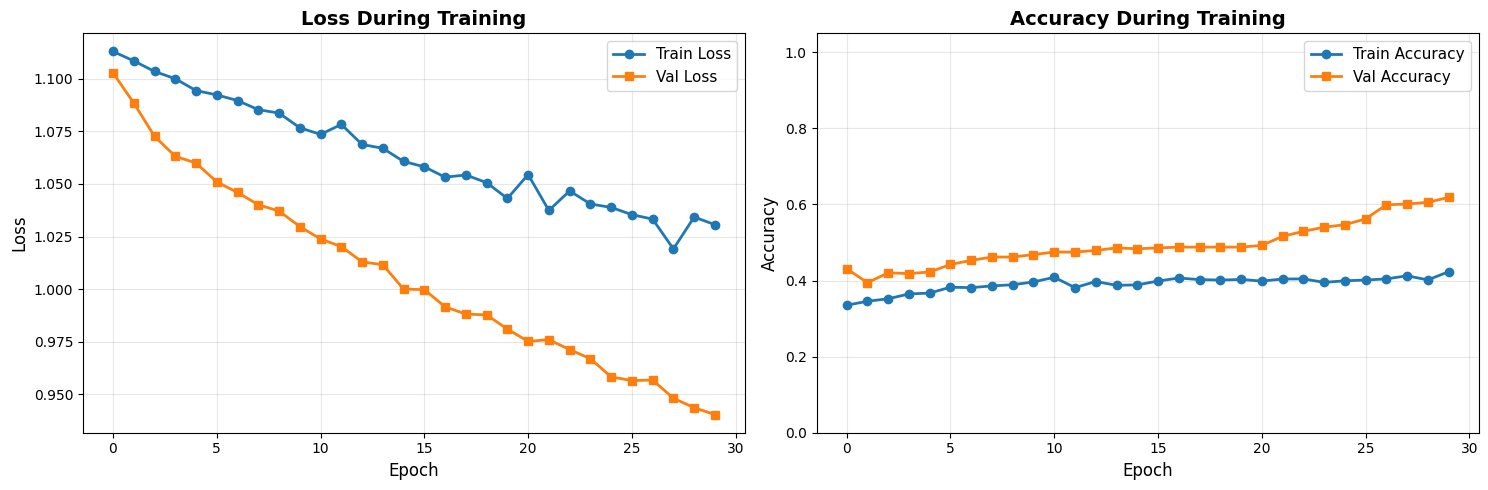


Training Summary:
Best Train Accuracy: 0.4233 (Epoch 30)
Best Val Accuracy:   0.6187 (Epoch 30)
Final Test Accuracy: 0.6519

Successfully observed real learning process from scratch!


In [8]:
import torch
from torch.optim import Adam
import torch.nn as nn
from tqdm import tqdm
import numpy as np

# Device selection: CUDA (NVIDIA GPU) -> MPS (Apple Silicon GPU) -> CPU
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = "mps"  # Apple Silicon GPU (M1/M2/M3)
else:
    device = "cpu"

# Create ResNet18 model that will learn from scratch
# pretrained=False -> no prior knowledge, model learns everything from scratch
model = ResNet18Classifier(num_classes=3, pretrained=False, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()

# Learning rate for model learning from scratch
optimizer = Adam(model.parameters(), lr=0.0000001, weight_decay=1e-4)

print(f"Using device: {device}")
print(f"Model: ResNet18 (Training from scratch - NO pre-training!)")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Dropout: 0.3")
print("\nStarting training...\n")

def evaluate(loader, verbose=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    avg_loss = total_loss / len(loader)
    
    if verbose:
        # Detailed check - what is the model predicting?
        print(f"\nSample predictions (first 20):")
        for i in range(min(20, len(all_preds))):
            print(f"  True: {all_labels[i]}, Predicted: {all_preds[i]}, {'✓' if all_preds[i] == all_labels[i] else '✗'}")
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)
    
    return accuracy, avg_loss

# Initial evaluation before training
print("\n" + "="*60)
print("=== Initial Evaluation (Before Training) ===")
print("="*60)
initial_train_acc, initial_train_loss = evaluate(train_loader, verbose=True)
initial_val_acc, initial_val_loss = evaluate(val_loader)
print(f"\nTrain Acc (before): {initial_train_acc:.4f}")
print(f"Val Acc (before):   {initial_val_acc:.4f}")
print("="*60)

# Track training progress - save performance at each epoch
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

num_epochs = 30  # More epochs to see learning process

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    print(f"\n=== Epoch {epoch+1} ===")

    # tqdm for nice progress bar
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation calculations
    train_accuracy, train_loss = evaluate(train_loader)
    val_accuracy, val_loss = evaluate(val_loader)
    
    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_accuracy:.4f}")

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET (Never seen during training)")
print("="*60)
test_accuracy, test_loss = evaluate(test_loader, verbose=True)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Display training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: Loss over time
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graph 2: Accuracy over time
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Training Summary:")
print("="*60)
print(f"Best Train Accuracy: {max(history['train_acc']):.4f} (Epoch {history['train_acc'].index(max(history['train_acc']))+1})")
print(f"Best Val Accuracy:   {max(history['val_acc']):.4f} (Epoch {history['val_acc'].index(max(history['val_acc']))+1})")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"\nSuccessfully observed real learning process from scratch!")